### Data Cleaning and Preprocessing

This project focuses on cleaning and preparing an e-commerce delivery dataset using Python and Pandas. The dataset is processed to improve data quality before performing analysis.

In [1]:
import pandas as pd
dataset=pd.read_csv('Ecommerce_Delivery_Analytics.csv')

In [2]:
dataset.head()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,2025-07-18 07:21:28,30,Fruits & Vegetables,382,"Fast delivery, great service!",5.0,No,No
1,ORD000002,CUST1409,Blinkit,2025-11-18 19:53:15,16,Dairy,279,Quick and reliable!,5.0,No,No
2,ORD000003,CUST5506,JioMart,2025-06-27 18:12:28,25,Beverages,599,Items missing from order.,2.0,No,Yes
3,ORD000004,CUST5012,JioMart,2025-12-23 02:16:28,42,Beverages,946,Items missing from order.,2.0,Yes,Yes
4,ORD000005,CUST4657,Blinkit,2025-02-01 15:06:08,30,Beverages,334,"Fast delivery, great service!",5.0,No,No


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 100150 entries, 0 to 100149
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order ID                 100150 non-null  str    
 1   Customer ID              100150 non-null  str    
 2   Platform                 100150 non-null  str    
 3   Order Date & Time        100150 non-null  str    
 4   Delivery Time (Minutes)  100150 non-null  int64  
 5   Product Category         100150 non-null  str    
 6   Order Value (INR)        100150 non-null  int64  
 7   Customer Feedback        98146 non-null   str    
 8   Service Rating           99148 non-null   float64
 9   Delivery Delay           100150 non-null  str    
 10  Refund Requested         100150 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 8.4 MB


In [4]:
dataset['Order Date & Time']=pd.to_datetime(dataset['Order Date & Time'])

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 100150 entries, 0 to 100149
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Order ID                 100150 non-null  str           
 1   Customer ID              100150 non-null  str           
 2   Platform                 100150 non-null  str           
 3   Order Date & Time        100150 non-null  datetime64[us]
 4   Delivery Time (Minutes)  100150 non-null  int64         
 5   Product Category         100150 non-null  str           
 6   Order Value (INR)        100150 non-null  int64         
 7   Customer Feedback        98146 non-null   str           
 8   Service Rating           99148 non-null   float64       
 9   Delivery Delay           100150 non-null  str           
 10  Refund Requested         100150 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(7)
memory usage: 8.4 MB


In [6]:
dataset.duplicated().sum()

np.int64(0)

In [7]:
dataset.isnull().sum()

Order ID                      0
Customer ID                   0
Platform                      0
Order Date & Time             0
Delivery Time (Minutes)       0
Product Category              0
Order Value (INR)             0
Customer Feedback          2004
Service Rating             1002
Delivery Delay                0
Refund Requested              0
dtype: int64

In [8]:
dataset['Customer Feedback'].unique()

<StringArray>
[             'Fast delivery, great service!',
                        'Quick and reliable!',
                  'Items missing from order.',
 'Horrible experience, never ordering again.',
           'Very satisfied with the service.',
             'Very late delivery, not happy.',
                      'Excellent experience!',
                   'Easy to order, loved it!',
                     'Good quality products.',
                   'Not fresh, disappointed.',
                      'Wrong item delivered.',
                  'Delivery person was rude.',
                 'Packaging could be better.',
                                          nan]
Length: 14, dtype: str

In [9]:
dataset['Customer Feedback'] = dataset['Customer Feedback'].fillna('No Feedback')

In [10]:
dataset['Customer Feedback'].unique()

<StringArray>
[             'Fast delivery, great service!',
                        'Quick and reliable!',
                  'Items missing from order.',
 'Horrible experience, never ordering again.',
           'Very satisfied with the service.',
             'Very late delivery, not happy.',
                      'Excellent experience!',
                   'Easy to order, loved it!',
                     'Good quality products.',
                   'Not fresh, disappointed.',
                      'Wrong item delivered.',
                  'Delivery person was rude.',
                 'Packaging could be better.',
                                'No Feedback']
Length: 14, dtype: str

In [11]:
dataset.describe()

,Order Date & Time,Delivery Time (Minutes),Order Value (INR),Service Rating
count,100150,100150.000000,100150.000000,99148.000000
mean,2025-07-02 20:49:52.095566,29.530065,590.986780,3.240378
min,2025-01-01 00:00:49,-5.000000,50.000000,1.000000
25%,2025-04-02 14:42:07,23.000000,283.000000,2.000000
50%,2025-07-02 19:05:29,30.000000,481.000000,3.000000
75%,2025-10-02 01:24:25.500000,36.000000,770.000000,5.000000
max,2025-12-31 23:44:13,76.000000,2000.000000,5.000000
std,NaN,9.968759,417.441985,1.575735


In [12]:
dataset['Service Rating'].unique()

array([ 5.,  2.,  1.,  4.,  3., nan])

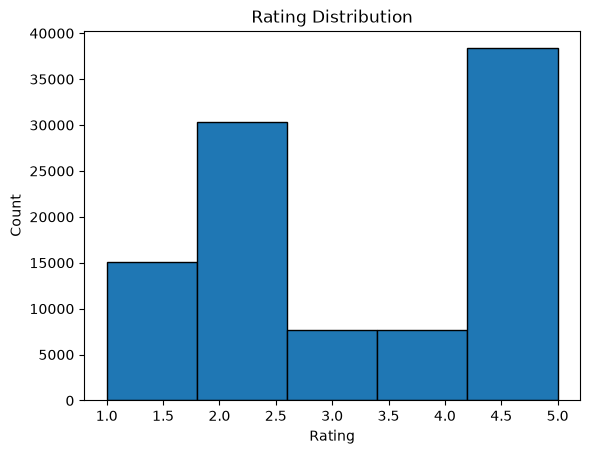

In [13]:
import matplotlib.pyplot as plt
dataset['Service Rating'].hist(bins=5,grid=False,edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [14]:
median_rating=dataset['Service Rating'].median()
dataset['Service Rating']=dataset['Service Rating'].fillna(median_rating)

In [15]:
dataset.isnull().sum()

Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

In [16]:
dataset['Delivery Time (Minutes)'].sample(10)

91305     26
56637     41
74765     29
100131    43
84588     40
35406     15
98470     41
81118      5
64048     33
82004     31
Name: Delivery Time (Minutes), dtype: int64

In [17]:
dataset['Product Category'].unique()

<StringArray>
[ 'Fruits & Vegetables',                'Dairy',            'Beverages',
        'Personal Care',              'Grocery',               'Snacks',
               'snacks',            'BEVERAGES',           'Beverages ',
              'Snacks ',        'personal care',               'SNACKS',
                'dairy',             'Grocery ',  'fruits & vegetables',
                'DAIRY',  'FRUITS & VEGETABLES',        'PERSONAL CARE',
 'Fruits & Vegetables ',              'grocery',            'beverages',
       'Personal Care ',              'GROCERY',               'Dairy ']
Length: 24, dtype: str

In [18]:
dataset['Product Category']=dataset['Product Category'].str.strip().str.title()

In [19]:
dataset['Product Category'].unique()

<StringArray>
['Fruits & Vegetables',               'Dairy',           'Beverages',
       'Personal Care',             'Grocery',              'Snacks']
Length: 6, dtype: str

In [20]:
dataset.columns=dataset.columns.str.lower().str.replace(' ','_')

In [21]:
dataset.sample(10)

,order_id,customer_id,platform,order_date_&_time,delivery_time_(minutes),product_category,order_value_(inr),customer_feedback,service_rating,delivery_delay,refund_requested
65880,ORD065881,CUST9180,Blinkit,2025-03-11 08:31:01,34,Fruits & Vegetables,230,No Feedback,2.0,No,Yes
2008,ORD002009,CUST4159,Swiggy Instamart,2025-04-24 18:59:51,33,Snacks,188,Delivery person was rude.,2.0,No,Yes
23409,ORD023410,CUST3147,Blinkit,2025-01-23 13:03:01,17,Personal Care,980,Items missing from order.,2.0,No,Yes
54651,ORD054652,CUST6535,JioMart,2025-06-10 02:39:23,22,Beverages,852,Items missing from order.,2.0,No,Yes
90895,ORD090896,CUST5869,Swiggy Instamart,2025-09-11 20:39:53,26,Dairy,778,"Not fresh, disappointed.",2.0,No,Yes
19339,ORD019340,CUST2175,Blinkit,2025-06-10 13:56:58,28,Dairy,755,Wrong item delivered.,1.0,No,Yes
35288,ORD035289,CUST7739,Swiggy Instamart,2025-11-27 04:11:22,31,Dairy,188,Excellent experience!,5.0,No,No
21858,ORD021859,CUST1168,Blinkit,2025-11-29 22:07:44,32,Snacks,268,Packaging could be better.,3.0,No,No
16816,ORD016817,CUST7241,Blinkit,2025-08-15 19:15:03,33,Snacks,204,"Not fresh, disappointed.",2.0,No,Yes
49019,ORD049020,CUST6414,JioMart,2025-10-20 02:06:07,27,Snacks,57,No Feedback,1.0,No,Yes


In [22]:
dataset.to_csv("Ecommerce_Delivery_Analytics_Cleaned.csv",index=False)

### Conclusion

The dataset has been successfully cleaned and is ready for exploratory data analysis and visualization. Proper data preprocessing helps ensure accurate and reliable insights.